# Setup

## OpenAI Key 등록
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [1]:
from dotenv import load_dotenv

load_dotenv()


True

# Vector DB

## Loader

In [2]:
from langchain_community.document_loaders import TextLoader

file_path = "./data/rag-keywords.txt"
loader = TextLoader(file_path, encoding='utf-8')

docs = loader.load()
print(f"로드된 파일의 수: {len(docs)}")

로드된 파일의 수: 1


## Splitter

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=0)

In [4]:
split_doc1 = text_splitter.split_documents(docs)
print(f"분리된 문서의 수: {len(split_doc1)}")

분리된 문서의 수: 11


## Embedding

In [5]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")


## ChromaDB

In [6]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=split_doc1, # 문서 리스트
    embedding=embeddings, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("파일이 Chroma VectorStore에 저장되었습니다.")

파일이 Chroma VectorStore에 저장되었습니다.


In [7]:
stats = vectorstore._collection.count()

print(f"저장된 문서 수: {stats}")

저장된 문서 수: 11


# [Retriever](https://docs.langchain.com/oss/python/integrations/retrievers)
- Retrieval Augmented Generation (RAG)에서 `검색도구(Retrievers)` 는 벡터 저장소에서 문서를 검색하는 도구입니다.
- LangChain은 간단한 의미 검색도구부터 성능 향상을 위해 고려된 다양한 검색 알고리즘을 지원합니다.

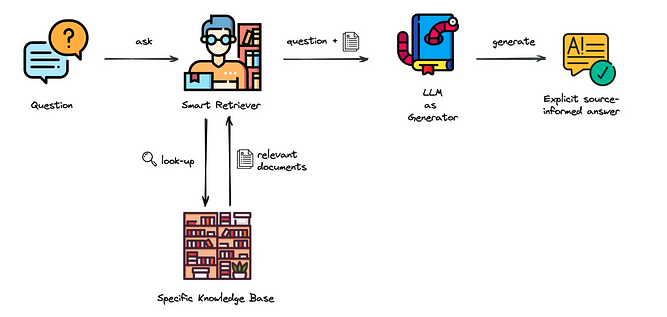

## Retriever 생성

In [8]:
# 데이터베이스를 검색기로 사용하기 위해 retriever 변수에 할당
retriever = vectorstore.as_retriever()

## [다중 쿼리 검색기](https://wikidocs.net/234109)
- 거리 기반 벡터 데이터베이스 검색은 고차원 공간에서의 쿼리 임베딩(표현)과 '거리'를 기준으로 유사한 임베딩을 가진 문서를 찾는 방식입니다. 하지만 쿼리의 세부적인 차이나 임베딩이 데이터의 의미를 제대로 포착하지 못할 경우, 검색 결과가 달라질 수 있습니다. 또한, 이를 수동으로 조정하는 프롬프트 엔지니어링이나 튜닝 작업은 번거로울 수 있습니다.
- 이런 문제를 해결하기 위해, `MultiQueryRetriever` 는 주어진 사용자 입력 쿼리에 대해 다양한 관점에서 여러 쿼리를 자동으로 생성하는 LLM(Language Learning Model)을 활용해 프롬프트 튜닝 과정을 자동화합니다.
- 이 방식은 각각의 쿼리에 대해 관련 문서 집합을 검색하고, 모든 쿼리를 아우르는 고유한 문서들의 합집합을 추출해, 잠재적으로 관련된 더 큰 문서 집합을 얻을 수 있게 해줍니다.
- 여러 관점에서 동일한 질문을 생성함으로써, `MultiQueryRetriever` 는 거리 기반 검색의 제한을 일정 부분 극복하고, 더욱 풍부한 검색 결과를 제공할 수 있습니다.

### LLM

In [9]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### MultiQueryRetriever

"하나의 질문을 여러 개의 의미적으로 유사한 쿼리로 확장" 해서 `벡터 스토어나 검색엔진에서 더 다양한 문서를 가져오는 역할`을 합니다.

In [10]:
import logging

# 로거 설정
logger = logging.getLogger("custom.multi_query_retriever")

#### 다중 쿼리 생성을 위한 프롬프트 템플릿

In [11]:
from langchain_core.prompts import PromptTemplate

query_generation_prompt = PromptTemplate(
    input_variables=["question"],
    template="""
        당신은 AI 언어 모델 어시스턴트입니다. 
        벡터 데이터베이스에서 관련 문서를 검색하기 위해 주어진 사용자 질문을 3가지 다른 버전으로 생성하는 것이 당신의 임무입니다.
        사용자 질문에 대해 여러 관점을 생성함으로써, 거리 기반 유사도 검색의 일부 한계를 극복하는 것이 목표입니다.

        이러한 대안 질문들을 줄바꿈으로 구분하여 제공하세요.

        원본 질문: {question}

        대안 질문들:"""
)

#### 쿼리 생성 체인 (LCEL)

In [12]:
from langchain_core.output_parsers import StrOutputParser

query_generation_chain = query_generation_prompt | llm | StrOutputParser()

#### LCEL로 전체 MultiQueryRetriever 파이프라인 구성

In [13]:
# 생성된 쿼리를 리스트로 파싱하는 함수
def parse_queries(output: str) -> dict:
    """생성된 쿼리 문자열을 리스트로 변환"""
    queries = [q.strip() for q in output.strip().split('\n') if q.strip()]
    logger.info(f"Generated alternative queries: {queries}")
    return {"queries": queries}

In [14]:
# 원본 질문과 생성된 쿼리를 합치는 함수
def add_original_query(data: dict) -> dict:
    """원본 질문을 쿼리 리스트에 추가"""
    original = data.get("question", "")
    queries = data.get("queries", [])
    # 원본 질문을 맨 앞에 추가
    all_queries = [original] + queries
    logger.info(f"All queries (including original): {all_queries}")
    return {"all_queries": all_queries}

In [15]:
# 각 쿼리로 문서를 검색하고 중복 제거하는 함수
def retrieve_and_deduplicate(data: dict) -> list:
    """모든 쿼리로 검색 후 중복 제거"""
    queries = data.get("all_queries", [])
    all_documents = []
    seen_contents = set()
    
    for query in queries:
        docs = retriever.invoke(query)
        logger.info(f"Query '{query}' retrieved {len(docs)} documents")
        
        # 중복 제거
        for doc in docs:
            content = doc.page_content
            if content not in seen_contents:
                seen_contents.add(content)
                all_documents.append(doc)
    
    logger.info(f"Total unique documents retrieved: {len(all_documents)}")
    return all_documents

In [16]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

# 입력 정규화 함수
def normalize_input(input_data):
    """입력을 문자열로 정규화"""
    if isinstance(input_data, str):
        return input_data
    elif isinstance(input_data, dict):
        return input_data.get("input") or input_data.get("question") or str(input_data)
    else:
        return str(input_data)

multiquery_retriever = (
    # 입력 정규화
    RunnableLambda(normalize_input)
    # 쿼리 생성
    | RunnableLambda(lambda question: {
        "question": question,
        "generated_output": query_generation_chain.invoke({"question": question})
    })
    # 생성된 쿼리를 파싱
    | RunnableLambda(lambda x: {
        "question": x["question"],
        "queries": [q.strip() for q in x["generated_output"].strip().split('\n') if q.strip()]
    })
    # 원본 질문 추가
    | RunnableLambda(add_original_query)
    # 검색 및 중복 제거
    | RunnableLambda(retrieve_and_deduplicate)
)


### 디버깅
- 아래는 다중 쿼리를 생성하는 중간 과정을 디버깅하기 위하여 실행하는 코드입니다.
- 먼저 `"langchain.retrievers.multi_query"` 로거를 가져옵니다.
- 이는 `logging.getLogger()` 함수를 사용하여 수행됩니다. 그 다음, 이 로거의 로그 레벨을 `INFO`로 설정하여, `INFO` 레벨 이상의 로그 메시지만 출력되도록 할 수 있습니다.

In [17]:
# 쿼리에 대한 로깅 설정
import logging

logging.basicConfig()
# 직접 구현한 MultiQueryRetriever의 로거 활성화
logging.getLogger("custom.multi_query_retriever").setLevel(logging.INFO)


- 이 코드는 `retriever_from_llm` 객체의 `invoke()` 메서드를 사용하여 주어진 `question`과 관련된 문서를 검색합니다.
- 검색된 문서들은 `unique_docs`라는 변수에 저장되며, 이 변수의 길이를 확인함으로써 검색된 관련 문서의 총 개수를 알 수 있습니다.
- 이 과정을 통해 사용자의 질문에 대한 관련 정보를 효과적으로 찾아내고 그 양을 파악할 수 있습니다.

In [18]:
# 질문을 정의합니다.
question = "TF IDF 에 대하여 알려줘"
# 문서 검색
relevant_docs = multiquery_retriever.invoke(input=question)

# 검색된 고유한 문서의 개수를 반환합니다.
print(f"""
    ==============================
    검색된 문서 개수: {len(relevant_docs)}
    =============================="""
)

if relevant_docs:
    # 검색된 문서의 내용을 출력합니다.
    print(relevant_docs[0].page_content)


INFO:custom.multi_query_retriever:All queries (including original): ['TF IDF 에 대하여 알려줘', 'TF IDF가 무엇이며, 수식은 어떻게 구성되고 각 구성요소의 의미는 무엇인가?', '정보검색 시스템에서 TF IDF를 쿼리와 문서를 벡터화하고 유사도를 평가하는 표준 워크플로우를 단계별로 설명해줘.', 'TF IDF의 한계점은 무엇이며, BM25, LSA/LSI, Word2Vec/Doc2Vec, BERT 등과 같은 대안이나 보완 방법과 비교해 언제 어떤 상황에서 더 적합한가?']
INFO:custom.multi_query_retriever:Query 'TF IDF 에 대하여 알려줘' retrieved 4 documents
INFO:custom.multi_query_retriever:Query 'TF IDF가 무엇이며, 수식은 어떻게 구성되고 각 구성요소의 의미는 무엇인가?' retrieved 4 documents
INFO:custom.multi_query_retriever:Query '정보검색 시스템에서 TF IDF를 쿼리와 문서를 벡터화하고 유사도를 평가하는 표준 워크플로우를 단계별로 설명해줘.' retrieved 4 documents
INFO:custom.multi_query_retriever:Query 'TF IDF의 한계점은 무엇이며, BM25, LSA/LSI, Word2Vec/Doc2Vec, BERT 등과 같은 대안이나 보완 방법과 비교해 언제 어떤 상황에서 더 적합한가?' retrieved 4 documents
INFO:custom.multi_query_retriever:Total unique documents retrieved: 7



    검색된 문서 개수: 7
정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema

정의: 스키마는 데이터베이스나 파일의 구조를 정의하는 것으로, 데이터가 어떻게 저장되고 조직되는지에 대한 청사진을 제공합니다.
예시: 관계형 데이터베이스의 테이블 스키마는 열 이름, 데이터 타입, 키 제약 조건 등을 정의합니다.
연관키워드: 데이터베이스, 데이터 모델링, 데이터 관리

DataFrame


## 간단한 RAG 예제

### PromptTemplate

In [19]:
from langchain_core.prompts import PromptTemplate

prompt_template = """
    다음 문서를 바탕으로 질문에 답변해주세요.
    
    문서:
    {context}
    
    질문: {question}
    
    답변: 문서의 내용을 바탕으로 정확하고 자세하게 답변해주세요.
"""
    
prompt = PromptTemplate.from_template(
    template=prompt_template
)

### LLM

In [20]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### RetrievalQA

In [21]:
# 문서를 문자열로 변환하는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# LCEL 방식의 RAG 체인 구성
qa_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [22]:
# 질문 답변 실행
question = "벡터 데이터베이스의 역할은 무엇인가요?"

# LCEL 체인에 질문을 문자열로 전달
answer = qa_chain.invoke(question)

print(f"질문: {question}")
print(f"답변: {answer}")

질문: 벡터 데이터베이스의 역할은 무엇인가요?
답변: - 벡터 데이터베이스의 역할은 벡터 형식으로 변환된 데이터를 저장하는 시스템으로, 검색, 분류 및 기타 데이터 분석 작업에 활용됩니다.
- 예시: 단어 임베딩 벡터들을 데이터베이스에 저장하여 필요할 때 빠르게 접근할 수 있습니다.
- 연관키워드: 임베딩, 데이터베이스, 벡터화

요약하면, 벡터스토어는 임베딩된 데이터를 저장하고 이를 바탕으로 빠른 검색과 다양한 분석을 가능하게 하는 저장소 역할을 합니다.
